In [ ]:
# trying to figure out dice loss and validation

In [1]:
import optuna
import os, warnings
from pathlib import Path
from glob import glob

import numpy as np 
import scipy as sp
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import glob
from PIL import Image
import seaborn as sns
import torch
import torchvision
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.colors import LinearSegmentedColormap



import flyr
import vinesthermal as vt

In [2]:
from vinesthermal import FlirDataset
from vinesthermal import UNet
from vinesthermal import dice_loss

In [12]:
#name the datasets
dataset_path = "/Users/ameliakeyser-gibson/Documents/SEFS/Kim Lab/vines grant/thermal/monthly images"
image_subsize = 128
stride = 32

test_ds = FlirDataset(dataset_path, datatype="test", image_subsize=image_subsize)
train_eval_ds = FlirDataset(dataset_path, datatype="train", image_subsize=image_subsize) # what is this - from the optuna code and used below
val_ds = FlirDataset(dataset_path, datatype="validation", image_subsize=image_subsize)

In [4]:
len(val_ds)

36

In [5]:
# loading the trained model
model = UNet(base_model = 'resnet18')
weights = torch.load("/Users/ameliakeyser-gibson/Documents/SEFS/Kim Lab/vines grant/thermal/optuna_lr-0.0009046296112615856_gamma-0.9678318664434684_bs-174.pt")
model.load_state_dict(weights, strict = False)

<All keys matched successfully>

In [6]:
preds_full = val_ds.pred_images(model)

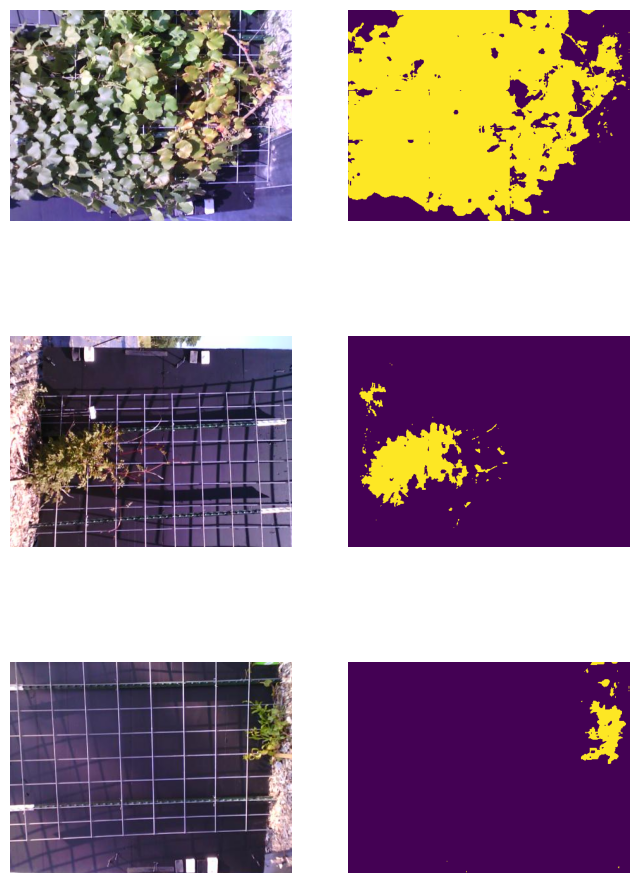

In [7]:
ims = [0,1,2]  

fig, axes = plt.subplots(len(ims), 2, figsize=(8, 4 * len(ims)))

for row, idx in enumerate(ims):
    im = list(preds_full.keys())[idx]
    pred = preds_full[im]
    thr, opt = val_ds.images[im]
    
    axes[row, 0].imshow(opt)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(pred > 0.8, vmin=0, vmax=1)
    axes[row, 1].axis('off')

plt.show()

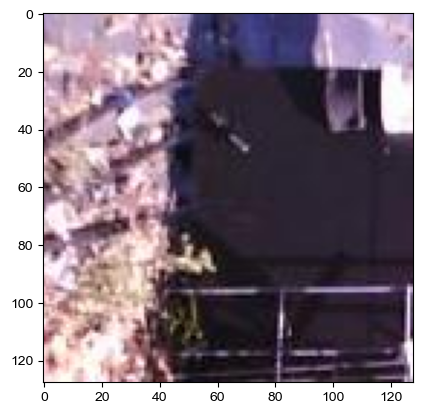

In [34]:
im = val_ds.sample_data["FLIR2403",0,0][3]
plt.imshow(im)

In [13]:
# Make the dataloaders:
test_dloader = torch.utils.data.DataLoader(test_ds,batch_size=8,shuffle=False, drop_last=False)
train_eval_dloader = torch.utils.data.DataLoader(train_eval_ds, batch_size=8, shuffle=False, drop_last=False)
val_dloader = torch.utils.data.DataLoader(val_ds, batch_size=8, shuffle=False, drop_last=False)


In [14]:
#evaluating model to get dice loss - code from optuna script

# Declare our loss function: what's actually getting minimized
dice_loss_fn = lambda a, b: dice_loss(a, b, smoothing=1, logits=True)

with torch.no_grad(): # not training
    model.eval()
    total_test_dice_loss = 0
    for (inputs, targets) in test_dloader:
        preds = model(inputs)
        total_test_dice_loss += float(dice_loss_fn(preds, targets).detach()) * len(targets)
    mean_test_dice_loss = total_test_dice_loss / len(test_ds)

    total_train_dice_loss = 0
    for (inputs, targets) in train_eval_dloader:
        preds = model(inputs)
        total_train_dice_loss += float(dice_loss_fn(preds, targets).detach()) * len(targets)
    mean_train_dice_loss = total_train_dice_loss / len(train_eval_ds)
 
    total_val_dice_loss = 0
    for (inputs, targets) in val_dloader:
        preds = model(inputs)
        total_val_dice_loss += float(dice_loss_fn(preds, targets).detach()) * len(targets)
    mean_val_dice_loss = total_val_dice_loss / len(val_ds)
 
print("Dice loss results:")
print(f"  train dice loss      = {mean_train_dice_loss:.4f}")
print(f"  validation dice loss = {mean_val_dice_loss:.4f}")
print(f"  test dice loss       = {mean_test_dice_loss:.4f}")

Dice loss results:
  train dice loss      = 0.5063
  validation dice loss = 0.0990
  test dice loss       = 0.1807


In [54]:
# per item dice loss test dataset
model.eval()
sample_keys = list(test_ds.sample_data.keys())

rows = []

with torch.no_grad():
    for inputs, targets in test_dloader:
        preds = (torch.sigmoid(model(inputs)) > 0.8).float()
        for i in range(len(targets)):
            #t_sum = targets[i].sum().item()  #counts how many total pixels should be the target class
            #p_sum = preds[i].sum().item()
            d = dice_loss(preds[i], targets[i]).item()
            filename, rno, cno = sample_keys[idx]
            rows.append((filename, rno, cno, d))
            idx += 1

assert idx == len(sample_keys), (idx, len(sample_keys))

test_dice_loss2 = pd.DataFrame(
    rows, columns=["filename", "rno", "cno", "dice_loss"])

In [17]:
test_dice_loss['dice_loss'].min()

np.float64(0.0)

In [55]:
test_dice_loss2

,filename,rno,cno,dice_loss
0,FLIR3349,0,0,0.274270
1,FLIR3349,0,1,0.259524
2,FLIR3349,0,2,0.131354
3,FLIR3349,0,3,0.209963
4,FLIR3349,1,0,0.136908
...,...,...,...,...
79,FLIR2831,1,3,0.001317
80,FLIR2831,2,0,0.051333
81,FLIR2831,2,1,0.021859
82,FLIR2831,2,2,0.031364


In [18]:
test_dice_loss['dice_loss'].max()

np.float64(0.4736033082008362)

In [19]:
test_dice_loss['dice_loss'].mean()

np.float64(0.1263966337899633)

<Axes: ylabel='dice_loss'>

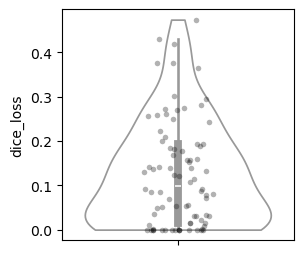

In [20]:
plt.figure(figsize=(3, 3))

#violin plot
sns.violinplot(data=test_dice_loss, y="dice_loss", inner="box", 
    color="white", cut = 0)

sns.stripplot(y="dice_loss",data=test_dice_loss,color="black",alpha=0.3, jitter=0.15, size=4)

In [22]:
test_dice_loss.to_csv("/Users/ameliakeyser-gibson/Documents/SEFS/Kim Lab/vines grant/thermal/test_dice_loss2.csv")

In [63]:
# per item dice loss validation dataset
model.eval()
sample_keys = list(val_ds.sample_data.keys())

rows = []
idx = 0
with torch.no_grad():
    for inputs, targets in val_dloader:
        preds = (torch.sigmoid(model(inputs)) > 0.8).float() # apply same threshold
        for i in range(len(targets)):
            d = dice_loss(preds[i], targets[i]).item()
            filename, rno, cno = sample_keys[idx]
            rows.append((filename, rno, cno, d))
            idx += 1
val_dice_loss = pd.DataFrame(
    rows, columns=["filename", "rno", "cno", "dice_loss"])

In [25]:
val_dice_loss.to_csv("/Users/ameliakeyser-gibson/Documents/SEFS/Kim Lab/vines grant/thermal/val_dice_loss2.csv")

In [64]:
val_dice_loss

,filename,rno,cno,dice_loss
0,FLIR1547,0,0,0.070243
1,FLIR1547,0,1,0.031816
2,FLIR1547,0,2,0.065657
3,FLIR1547,0,3,0.132240
4,FLIR1547,1,0,0.053332
5,FLIR1547,1,1,0.059013
6,FLIR1547,1,2,0.070823
7,FLIR1547,1,3,0.112764
8,FLIR1547,2,0,0.069242
9,FLIR1547,2,1,0.049557


<Axes: ylabel='dice_loss'>

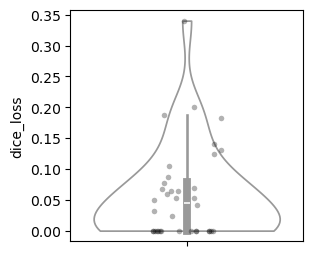

In [21]:
plt.figure(figsize=(3, 3))

#violin plot
sns.violinplot(data=val_dice_loss, y="dice_loss", inner="box", 
    color="white", cut = 0)

sns.stripplot(y="dice_loss",data=val_dice_loss,color="black",alpha=0.3, jitter=0.15, size=4)

In [26]:
#val_dice_loss

In [28]:
# pull out a couple points and show RGB and segmentation results - one is high
#test dataset
(imgstack, segstack, trgstack) = test_ds.pred_all(model)

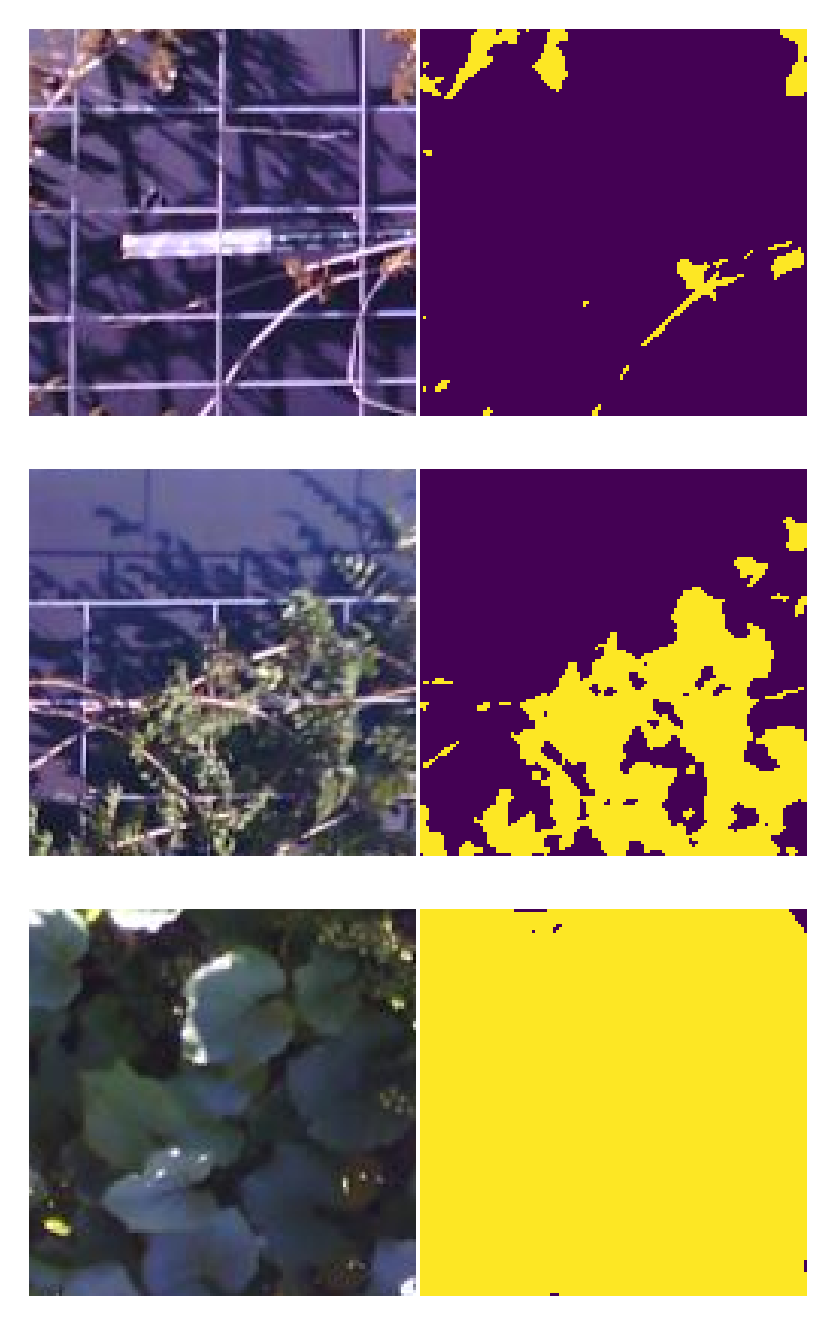

In [52]:
imnos = [28, 3, 78]
nims = len(imnos)

(fig, axs) = plt.subplots(nims, 2, figsize=(3, 1.5 * nims), dpi=288)
fig.subplots_adjust(left=0, bottom=0, right=0.9, top=1, wspace=0.01, hspace=0.06)
imgs = imgstack[imnos]
segs = segstack[imnos]

for (img, seg, axrow) in zip(imgs, segs, axs):
    axrow[0].imshow(img)
    axrow[1].imshow(seg > 0.8, vmin=0, vmax=1)
for ax in axs.flat:
    ax.axis('off')
plt.savefig("test_ex.png")
plt.show()


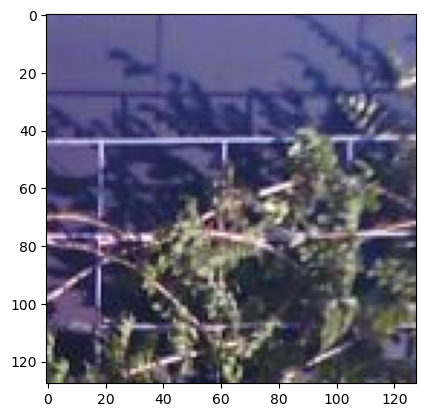

In [34]:
# double checking it's the correct im
im = test_ds.sample_data["FLIR3349",0,3][2]
plt.imshow(im)

In [35]:
(imgstack1, segstack1, trgstack1) = val_ds.pred_all(model)

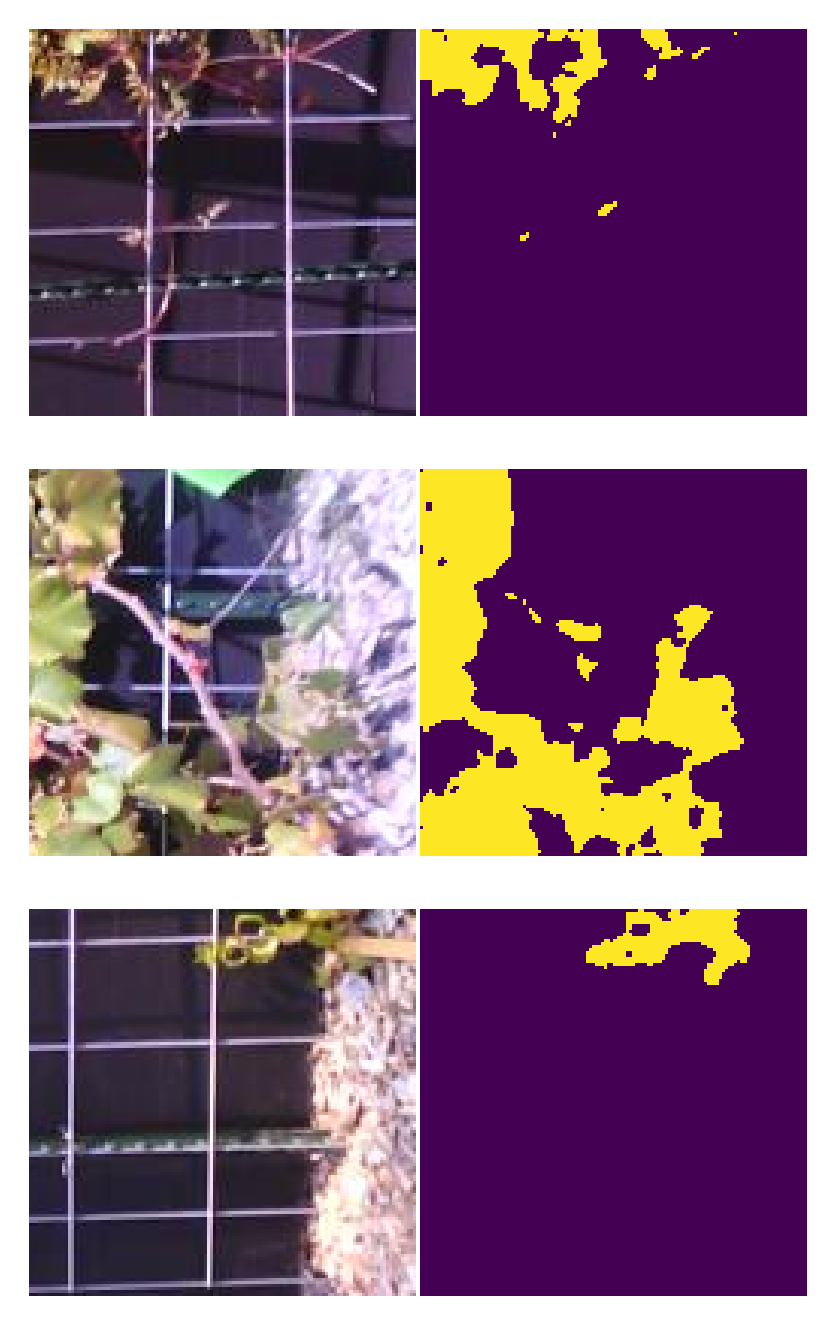

In [51]:
imnos = [21, 3, 31]
nims = len(imnos)

(fig, axs) = plt.subplots(nims, 2, figsize=(3, 1.5 * nims), dpi=288)
fig.subplots_adjust(left=0, bottom=0, right=0.9, top=1, wspace=0.01, hspace=0.06)
imgs = imgstack1[imnos]
segs = segstack1[imnos]

for (img, seg, axrow) in zip(imgs, segs, axs):
    axrow[0].imshow(img)
    axrow[1].imshow(seg > 0.8, vmin=0, vmax=1)
for ax in axs.flat:
    ax.axis('off')
plt.savefig("val_ex.png")
plt.show()

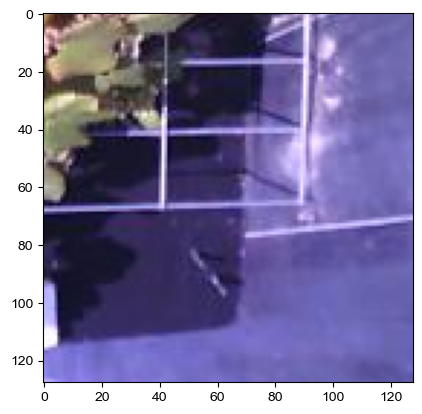

In [180]:
im = val_ds.sample_data["FLIR1547",2,3][2]
plt.imshow(im)

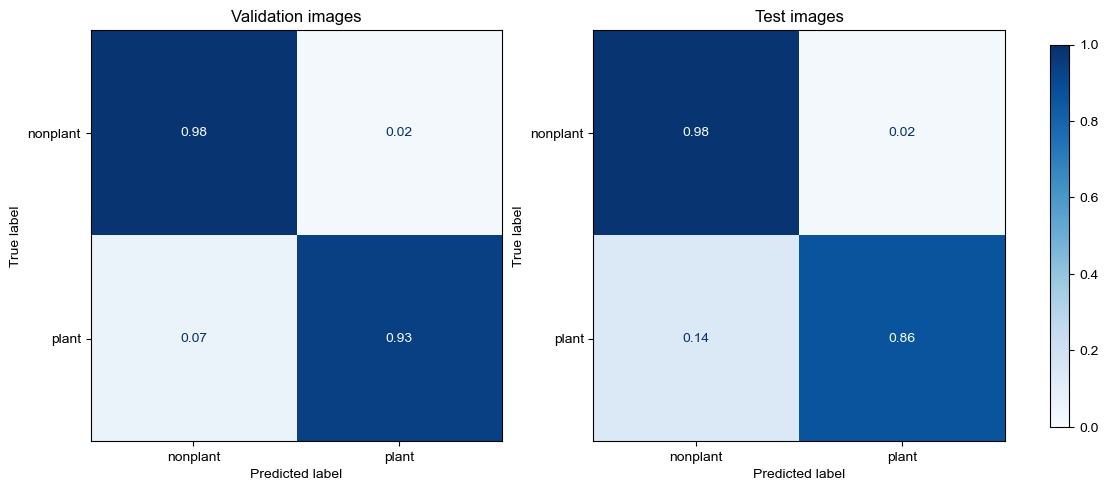

In [110]:
# confusion matrix!

model.eval()

# validation 
y_val_true = []
y_val_pred = []

with torch.no_grad():
    for images, masks in val_dloader:
        outputs = model(images)

        # convert logits to probabilities
        prob = torch.sigmoid(outputs)

        # apply threshold (0.8) that we use in the model
        preds = (prob > 0.8).int()

        # flatten the 2D images/masks into a 1D list of pixels and convert to numpy
        y_val_true.extend(masks.int().view(-1).numpy())
        y_val_pred.extend(preds.view(-1).numpy())

cm_val = confusion_matrix(y_val_true, y_val_pred, labels=[0, 1], normalize='true')

# test
y_test_true = []
y_test_pred = []

with torch.no_grad():
    for images, masks in test_dloader:
        outputs = model(images)
        prob = torch.sigmoid(outputs)
        preds = (prob > 0.8).int()

        y_test_true.extend(masks.int().view(-1).numpy())
        y_test_pred.extend(preds.view(-1).numpy())

cm_test = confusion_matrix(y_test_true, y_test_pred, labels=[0, 1], normalize='true')

# plot 
plt.rcParams['font.sans-serif'] = ['Arial'] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['nonplant', 'plant'])
disp_val.plot(ax=ax1, cmap=plt.cm.Blues, values_format='.2f', colorbar=False)
disp_val.im_.set_clim(0, 1)
ax1.set_title("Validation images")

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['nonplant', 'plant'])
disp_test.plot(ax=ax2, cmap=plt.cm.Blues, values_format='.2f', colorbar=False)
disp_test.im_.set_clim(0, 1)
ax2.set_title("Test images")

# one shared colorbar
fig.colorbar(disp_test.im_, ax=[ax1, ax2], ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], shrink=0.8)
#plt.savefig("confusion.png")

plt.show()

In [204]:
from matplotlib.colors import LinearSegmentedColormap

In [67]:
val_cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#FFFFFF', '#FE5E41BF'])
test_cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#FFFFFF', '#C6D8AF'])

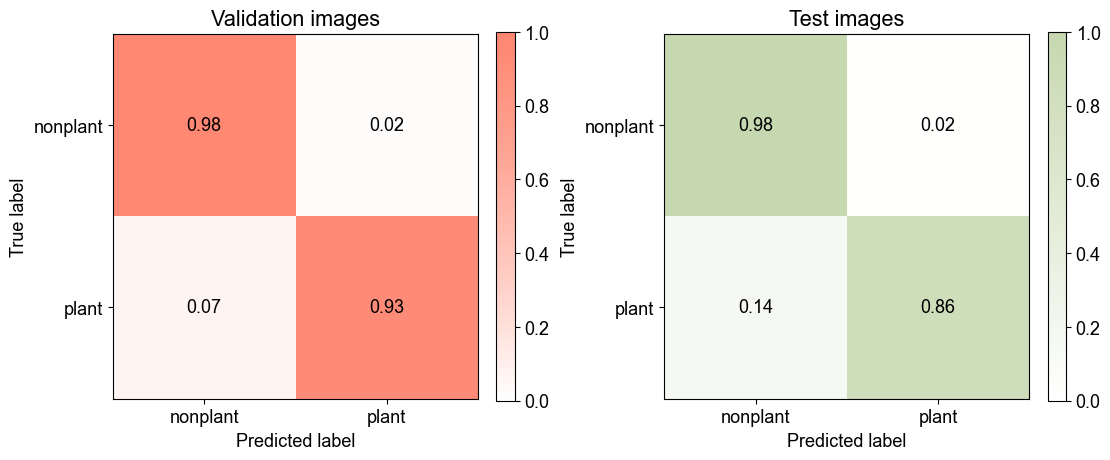

In [80]:
# confusion matrix!

model.eval()

# validation 
y_val_true = []
y_val_pred = []

with torch.no_grad():
    for images, masks in val_dloader:
        outputs = model(images)

        # convert logits to probabilities
        prob = torch.sigmoid(outputs)

        # apply threshold (0.8) that we use in the model
        preds = (prob > 0.8).int()

        # flatten the 2D images/masks into a 1D list of pixels and convert to numpy
        y_val_true.extend(masks.int().view(-1).numpy())
        y_val_pred.extend(preds.view(-1).numpy())

cm_val = confusion_matrix(y_val_true, y_val_pred, labels=[0, 1], normalize='true')

# test
y_test_true = []
y_test_pred = []

with torch.no_grad():
    for images, masks in test_dloader:
        outputs = model(images)
        prob = torch.sigmoid(outputs)
        preds = (prob > 0.8).int()

        y_test_true.extend(masks.int().view(-1).numpy())
        y_test_pred.extend(preds.view(-1).numpy())

cm_test = confusion_matrix(y_test_true, y_test_pred, labels=[0, 1], normalize='true')

# plot 
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams.update({'font.size': 13}) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['nonplant', 'plant'])
disp_val.plot(ax=ax1, cmap=val_cmap, values_format='.2f', colorbar=False, text_kw={'color': 'black'})
disp_val.im_.set_clim(0, 1)
fig.colorbar(disp_val.im_, ax=ax1, ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], shrink=0.75)
ax1.set_title("Validation images")

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['nonplant', 'plant'])
disp_test.plot(ax=ax2, cmap=test_cmap, values_format='.2f', colorbar=False, text_kw={'color': 'black'})
disp_test.im_.set_clim(0, 1)
fig.colorbar(disp_test.im_, ax=ax2, ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], shrink=0.75)
ax2.set_title("Test images")

# one shared colorbar
#fig.colorbar(disp_test.im_, ax=[ax1, ax2], ticks=[0, 0.2, 0.4, 0.6, 0.8, 1], shrink=0.8)
plt.savefig("confusion2.png")

plt.show()